# PyTorch Dataloading with NanoTST — Part 1: Map vs Iterable

**Today we're building the data loaders for NanoTST** — replacing its hand-rolled batching loop with PyTorch's real machinery.

By the end of this notebook you'll understand:

1. **The map** — what actually happens between your data and the model (`Dataset → sampler → DataLoader → collate → batch`)
2. **The two contracts** a Dataset can fulfill — map-style (`__len__` + `__getitem__`) and iterable-style (`__iter__`) — and when each is the right choice
3. **The worker model** — what `num_workers` really does, and why iterable datasets + workers silently duplicate your data

Key idea: **the DataLoader doesn't load your data — your Dataset does.** The DataLoader is machinery around whichever contract you implement.

## Background: what is NanoTST?

NanoTST is a nano time-series transformer built from scratch (see the [transformer-from-scratch series](../18_time-series-transformer-from-scratch)). PatchTST-style:

- A 512-point series is cut into **patches of 32 points — patches are the tokens**
- Instance-norm → patch embedding → 4 transformer blocks (multi-head causal attention) → Gaussian head
- Trained on **next-patch prediction** (Gaussian NLL): given patches 0..t, predict patch t+1

It trains on synthetic sine + trend + noise series, generated with known factors. All we care about today: **the model consumes batches of shape `[batch, 512]`** — our job is delivering them.

In [1]:
import math
import torch
from torch.utils.data import DataLoader, Subset

import nano_tst
import tst_data
from nano_tst import NanoTST
from tst_data import SeriesDataset, SyntheticSeriesStream, train_with_loader

torch.manual_seed(42)
print("torch", torch.__version__)

torch 2.2.2


## How NanoTST loads data today (the status quo)

The current training loop hand-slices one big tensor. This works — nanoGPT does the same thing — but **every piece of this loop has a name in PyTorch**:

In [2]:
import inspect
print(inspect.getsource(nano_tst.train_model))

def train_model(model, data, epochs=250, batch_size=32, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    for epoch in range(epochs):
        perm = torch.randperm(len(data))
        total_loss, n = 0, 0
        for i in range(0, len(data) - batch_size, batch_size):
            # Pass in one batch at a time
            loss = model.forward_and_loss(data[perm[i : i + batch_size]])
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            n += 1
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d} | MSE: {total_loss/n:.6f}")



Naming the parts:

- `torch.randperm(len(data))` — that's a **RandomSampler** (shuffling by permuting indices)
- `range(0, len(data) - batch_size, batch_size)` + the slice — that's a **batch sampler** with `drop_last=True`
- `data[perm[i:i+batch_size]]` — that's **`__getitem__` + collate** fused into one tensor index

We hand-rolled a sampler, a batcher, and drop_last without knowing it. Now let's build it properly — same behavior, named parts, and room to scale.

## The map

![dataloading map](dataloading_diagram.md)

```
Dataset ──(sampler picks order)──> DataLoader ──(workers + collate)──> batch tensor ──> model
 "where samples live"                "the machinery"                    "what trains"
```

The DataLoader is just calling `dataset[i]` (or `next(iter(dataset))`) batch_size times, then `collate` stacks the samples into one batch tensor. Everything else — shuffling, workers, pinning — is machinery around that.

## Contract 1: map-style — cheap random access

A map-style Dataset promises two things: `__len__` (how many samples) and `__getitem__` (give me sample *i*, cheaply). Because it's indexable, **the sampler owns the order** — shuffling is free, and a val split is just index filtering.

Map-style isn't "fits in memory" — it's **cheap random access**: in-memory tensors, memory-mapped files, parquet row groups all qualify.

In [3]:
print(inspect.getsource(SeriesDataset))

class SeriesDataset(Dataset):
    """All series precomputed in memory; indexing is free, so the sampler owns order."""

    def __init__(self, n_series: int = 1000, length: int = CONTEXT_LEN, seed: int = 77):
        generator = torch.Generator().manual_seed(seed)
        self.series = make_series(n_series, length, generator)

    def __len__(self) -> int:
        return len(self.series)

    def __getitem__(self, idx: int) -> torch.Tensor:
        return self.series[idx]



len(dataset) = 512
dataset[0].shape = torch.Size([512])


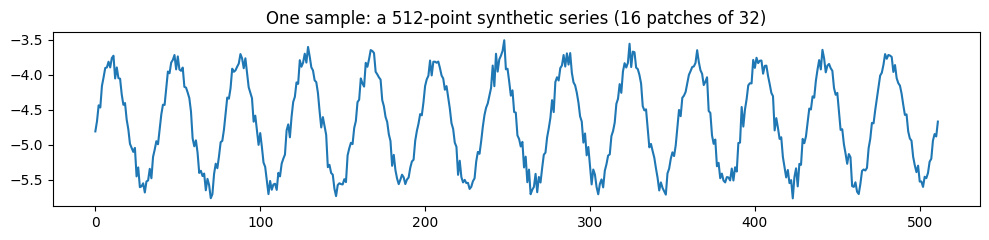

In [4]:
dataset = SeriesDataset(n_series=512)
print(f"len(dataset) = {len(dataset)}")
print(f"dataset[0].shape = {dataset[0].shape}")

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 2.5))
plt.plot(dataset[0])
plt.title("One sample: a 512-point synthetic series (16 patches of 32)")
plt.tight_layout()
plt.show()

In [5]:
# The hand-rolled loop, replaced — every argument is one of the parts we named
loader = DataLoader(
    dataset,
    batch_size=32,     # the batcher
    shuffle=True,      # the RandomSampler
    drop_last=True,    # the range() stop condition
)
batch = next(iter(loader))
print(f"batch.shape = {batch.shape}")   # [32, 512] — exactly what forward_and_loss expects

batch.shape = torch.Size([32, 512])


In [6]:
# Because the sampler owns order, splits are just index filtering
val_indices = [i for i in range(len(dataset)) if i % 10 == 0]
train_indices = [i for i in range(len(dataset)) if i % 10 != 0]
train_loader = DataLoader(Subset(dataset, train_indices), batch_size=32, shuffle=True, drop_last=True)
val_loader = DataLoader(Subset(dataset, val_indices), batch_size=32)
print(f"train: {len(train_indices)} samples, val: {len(val_indices)} samples")

train: 460 samples, val: 52 samples


### Train NanoTST on the DataLoader

The training loop barely changes — the loader owns delivery, the model owns the math:

In [7]:
model = NanoTST()
print(f"params: {sum(p.numel() for p in model.parameters()):,}")
losses_map = train_with_loader(model, train_loader, epochs=3)

params: 807,872


  Epoch 1 | loss: 1.6756 (14 steps)


  Epoch 2 | loss: 1.4211 (14 steps)


  Epoch 3 | loss: 1.3043 (14 steps)


## Contract 2: iterable-style — the stream

Now suppose the data **can't be indexed**: it's generated on demand, arrives from a socket, or lives in huge sharded files. Sample *i* doesn't exist until the iterator produces it.

That's the iterable contract: just `__iter__`. No `__len__`, no random access — which means **no sampler**. Order, shuffling, and splits are now *your* problem inside the dataset.

In [8]:
print(inspect.getsource(SyntheticSeriesStream))

class SyntheticSeriesStream(IterableDataset):
    """An infinite stream: series are generated on demand, one at a time.

    There is no __len__ and no __getitem__ — sample i doesn't exist until
    the iterator produces it. With shard_per_worker=False every DataLoader
    worker runs this same iterator and delivers identical samples (the
    duplication demo). With shard_per_worker=True each worker takes an
    interleaved slice of the stream via get_worker_info().
    """

    def __init__(self, seed: int = 77, length: int = CONTEXT_LEN,
                 shard_per_worker: bool = False):
        self.seed = seed
        self.length = length
        self.shard_per_worker = shard_per_worker

    def __iter__(self):
        start, step = 0, 1
        info = get_worker_info()
        if self.shard_per_worker and info is not None:
            start, step = info.id, info.num_workers
        index = start
        while True:
            yield series_at(self.seed, index, self.length)
        

In [9]:
stream = SyntheticSeriesStream(seed=77)

# There is no length — this isn't a limitation, it's the point
try:
    len(stream)
except TypeError as e:
    print(f"len(stream) -> TypeError: {e}")

it = iter(stream)
print("first three samples:", next(it).shape, next(it).shape, next(it).shape)

len(stream) -> TypeError: object of type 'SyntheticSeriesStream' has no len()
first three samples: torch.Size([512]) torch.Size([512]) torch.Size([512])


In [10]:
# Same DataLoader, same training loop — but now we cap steps, because the stream never ends
stream_loader = DataLoader(stream, batch_size=32)
model2 = NanoTST()
losses_stream = train_with_loader(model2, stream_loader, epochs=3, steps_per_epoch=14)

  Epoch 1 | loss: 1.6582 (14 steps)


  Epoch 2 | loss: 1.3878 (14 steps)


  Epoch 3 | loss: 1.2335 (14 steps)


## The worker model — where iterable bites

`num_workers=N` forks N worker processes, and **each worker runs your entire dataset**.

- Map-style: fine — the sampler splits *indices* across workers, each sample fetched once.
- Iterable: every worker runs the full iterator from the start. Same seed, same stream → **every sample delivered N times.**

In [11]:
# Naive: two workers, no sharding — the first two batches are IDENTICAL
naive_loader = DataLoader(SyntheticSeriesStream(seed=77), batch_size=4, num_workers=2)
it = iter(naive_loader)
b1, b2 = next(it), next(it)   # batch from worker 0, batch from worker 1
print("worker 0 and worker 1 delivered identical data:", torch.equal(b1, b2))
del it  # shut the workers down

worker 0 and worker 1 delivered identical data: True


In [12]:
# The fix: shard inside the iterator using get_worker_info()
# (worker k takes samples k, k+N, k+2N, ...)
sharded_loader = DataLoader(SyntheticSeriesStream(seed=77, shard_per_worker=True),
                            batch_size=4, num_workers=2)
it = iter(sharded_loader)
b1, b2 = next(it), next(it)
print("after sharding, batches identical:", torch.equal(b1, b2))
del it

after sharding, batches identical: False


This is the tell for the next video: DataLoader parallelism = **clone the whole reader N times**, then patch up the duplication yourself. Hold that thought.

## When to use which

| | map-style | iterable-style |
|---|---|---|
| contract | `__len__` + `__getitem__` | `__iter__` |
| use when | cheap random access (in-memory, mmap, indexed files) | streams, generated data, huge sharded datasets |
| shuffling | free (sampler owns order) | your problem (shuffle buffer / shard design) |
| splits | index filtering | your problem |
| workers | indices split automatically | shard by hand with `get_worker_info()` |

**Rule of thumb: map until you can't.**

Next: PyTorch is unbundling the DataLoader into composable nodes — same pipeline, rebuilt, and the sharding problem *dissolves*.